# Cold Plasma Waveguide — O-mode VQE Solver

This notebook solves the **O-mode** eigenvalue problem for a rectangular
waveguide filled with a cold magnetised plasma:

$$\left(-\frac{\partial^2}{\partial x^2} - \frac{\partial^2}{\partial y^2} + \frac{\omega_p^2(x,y)}{c^2}\right) E_3 = \frac{\omega^2}{c^2}\, E_3$$

where $\omega_p^2(x,y) = q_e^2 N_e(x,y) / (m_e \varepsilon_0)$.

We demonstrate both **uniform** and **non-uniform** (Gaussian) plasma density
profiles, solved with random VQE initialisation (no ML warm-start).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.coldplasma_vqe_waveguide import WaveguideModeVQA
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Uniform Plasma Density

We set a constant electron density $N_e = 10^{17}\;\text{m}^{-3}$ throughout
the waveguide cross-section.

In [3]:
Lx, Ly = 0.015, 0.010
nx, ny = 4, 3
n_layers = 4 + 3
NE_UNIFORM = 1e17

solver_uniform = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM',
    Lx=Lx, Ly=Ly,
    plasma_density=NE_UNIFORM
)

solver_uniform.print_plasma_info(1e6)

  Plasma-filled waveguide – O-mode solver
  Grid          : 16 x 8  (4+3 qubits)
  Waveguide     : Lx=15.0 mm, Ly=10.0 mm
  Cell size     : dx=937.50 µm, dy=1250.00 µm
  Plasma        : enabled
  Ne range      : [1.000e+17, 1.000e+17] m⁻³
  max ωp/(2π)   : 2.839 GHz
  ωc/(2π)       : 27.992 GHz
  Refraction idx: 0.940
  Eigenvalue = ω²/c²  (O-mode, Eq. 4.9)


Solving O-mode 0 (uniform plasma)...
Attempt 1 - Iter 243: Cost 144699.5360    
Mode 0 Result:
Eigenvalue λ = ω²/c² : 144699.535974598 m⁻²
Wave frequency  ω/(2π)  : 18.149907 GHz
(Plasma mode: eigenvalue includes ωp²/c² shift)

Numerical Eigenvalue (dense) : 144699.488563243 m⁻²
Cutoff / wave freq (numerical): 18.149904015 GHz
Relative Error vs numerical   : 0.000016383%


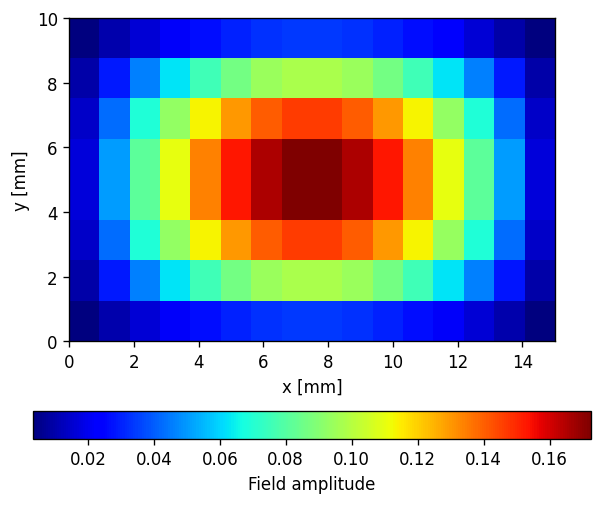

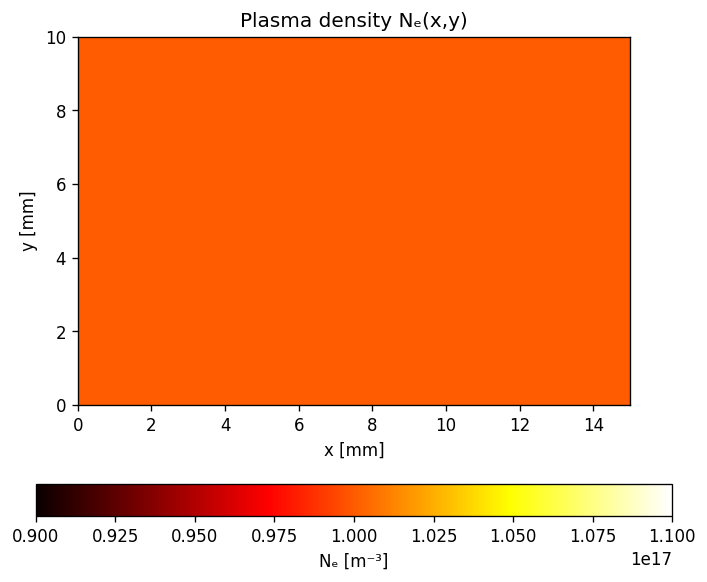

In [6]:
print('Solving O-mode 0 (uniform plasma)...')
eig_u0, params_u0, hist_u0 = solver_uniform.optimize_mode(k=0)
solver_uniform.print_plot_parameters(0, eig_u0, params_u0)

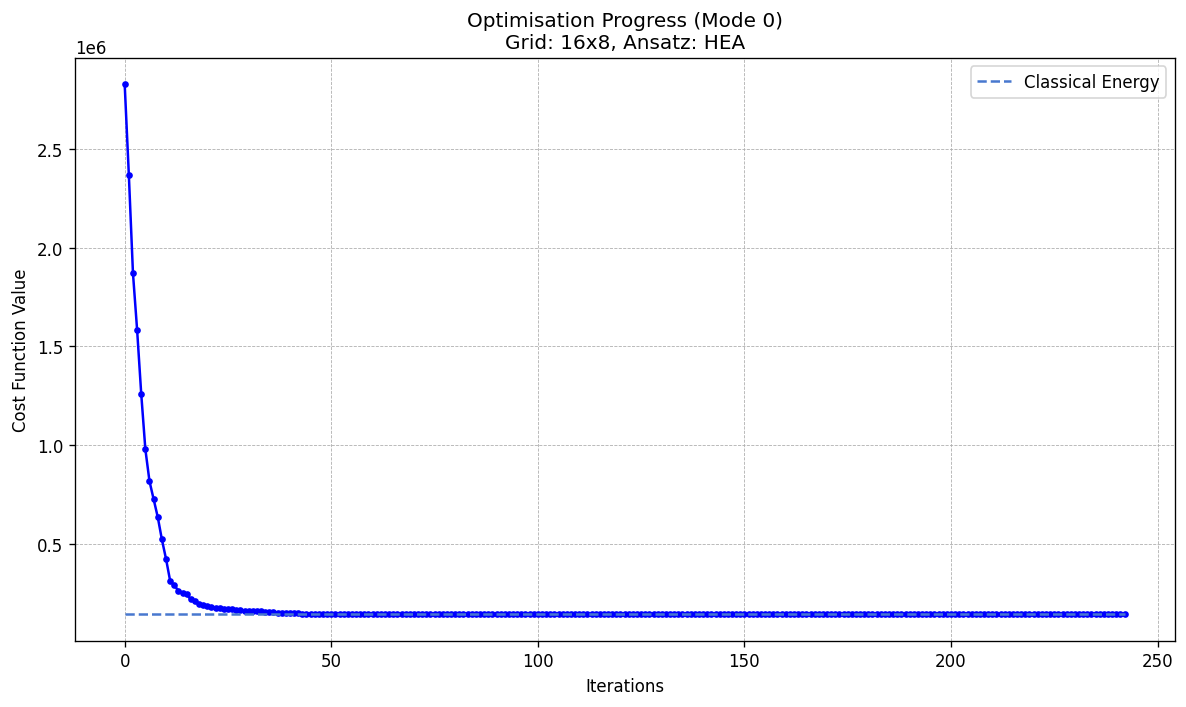

In [7]:
solver_uniform.plot_converge(hist_u0, k=0)

## 2. Gaussian Plasma Density Profile

A more realistic scenario with the density peaking at the centre:

$$N_e(x, y) = N_0 \cdot \exp\!\left(-\frac{(x - L_x/2)^2}{2\sigma_x^2} -\frac{(y - L_y/2)^2}{2\sigma_y^2}\right)$$

In [4]:
N0 = 5e17
sigma_x = Lx / 4
sigma_y = Ly / 4

def gaussian_density(x, y):
    return N0 * np.exp(
        -((x - Lx/2)**2) / (2 * sigma_x**2)
        -((y - Ly/2)**2) / (2 * sigma_y**2)
    )

solver_gauss = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM',
    Lx=Lx, Ly=Ly,
    Ne_func=gaussian_density
)

solver_gauss.print_plasma_info(1e6)

  Plasma-filled waveguide – O-mode solver
  Grid          : 16 x 8  (4+3 qubits)
  Waveguide     : Lx=15.0 mm, Ly=10.0 mm
  Cell size     : dx=937.50 µm, dy=1250.00 µm
  Plasma        : enabled
  Ne range      : [1.864e+16, 4.808e+17] m⁻³
  max ωp/(2π)   : 6.226 GHz
  ωc/(2π)       : 27.992 GHz
  Refraction idx: 0.870
  Eigenvalue = ω²/c²  (O-mode, Eq. 4.9)


Solving O-mode 0 (Gaussian plasma)...
Attempt 1 - Iter 100: Cost 152512.2606    
Mode 0 Result:
Eigenvalue λ = ω²/c² : 152512.260594124 m⁻²
Wave frequency  ω/(2π)  : 18.633447 GHz
(Plasma mode: eigenvalue includes ωp²/c² shift)

Numerical Eigenvalue (dense) : 152508.972500540 m⁻²
Cutoff / wave freq (numerical): 18.633246621 GHz
Relative Error vs numerical   : 0.001077994%


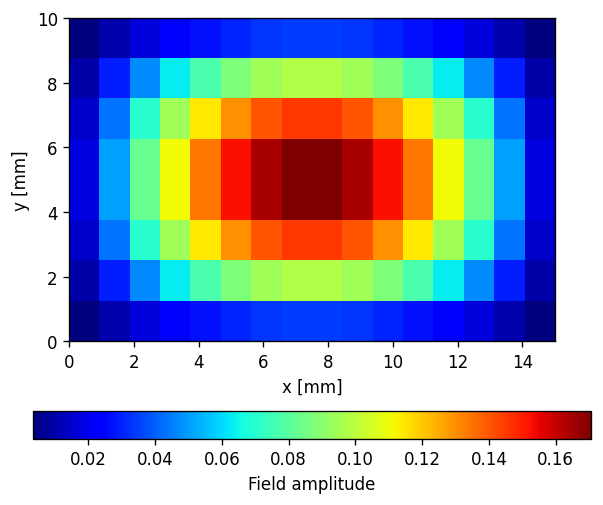

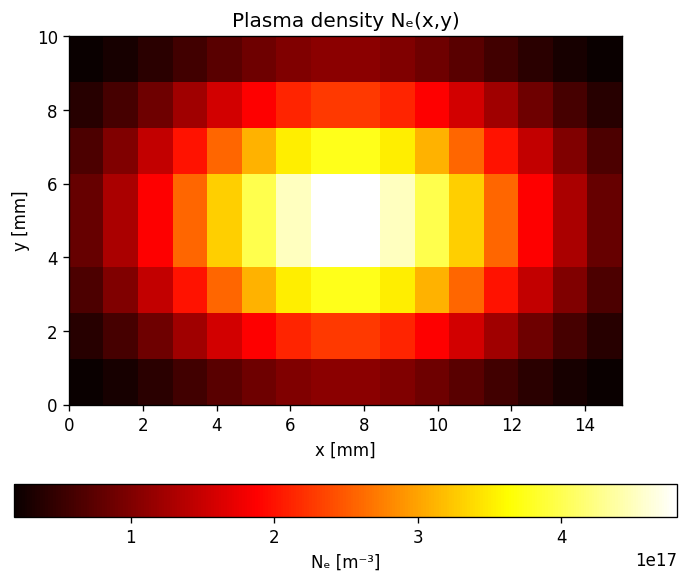

In [5]:
print('Solving O-mode 0 (Gaussian plasma)...')
eig_g0, params_g0, hist_g0 = solver_gauss.optimize_mode(k=0)
solver_gauss.print_plot_parameters(0, eig_g0, params_g0)

## 3. Density Sweep

Explore how the eigenvalue shifts as we increase the uniform plasma density.

In [6]:
densities = [0, 1e15, 1e16, 1e17, 5e17, 1e18]
results = []

s = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM', Lx=Lx, Ly=Ly,
    plasma_density= densities[0]
)
eig, _, _ = s.optimize_mode(k=0)
freq = s.compute_cutoff_frequency(eig) / 1e9
results.append((densities[0], eig, freq))
print(f'Ne = {densities[0]:.1e} m^-3  ->  lambda = {eig:.2f}  ->  f = {freq:.4f} GHz')

Ne = 0.0e+00 m^-3  ->  lambda = 141158.38  ->  f = 17.9264 GHz


In [7]:
s = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM', Lx=Lx, Ly=Ly,
    plasma_density= densities[1]
)

eig, _, _ = s.optimize_mode(k=0)
freq = s.compute_cutoff_frequency(eig) / 1e9
results.append((densities[1], eig, freq))
print(f'Ne = {densities[1]:.1e} m^-3  ->  lambda = {eig:.2f}  ->  f = {freq:.4f} GHz')

Ne = 1.0e+15 m^-3  ->  lambda = 141193.78  ->  f = 17.9287 GHz


In [8]:
s = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM', Lx=Lx, Ly=Ly,
    plasma_density= densities[2]
)

eig, _, _ = s.optimize_mode(k=0)
freq = s.compute_cutoff_frequency(eig) / 1e9
results.append((densities[2], eig, freq))
print(f'Ne = {densities[2]:.1e} m^-3  ->  lambda = {eig:.2f}  ->  f = {freq:.4f} GHz')

Ne = 1.0e+16 m^-3  ->  lambda = 141512.78  ->  f = 17.9489 GHz


In [9]:
s = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM', Lx=Lx, Ly=Ly,
    plasma_density= densities[3]
)

eig, _, _ = s.optimize_mode(k=0)
freq = s.compute_cutoff_frequency(eig) / 1e9
results.append((densities[3], eig, freq))
print(f'Ne = {densities[3]:.1e} m^-3  ->  lambda = {eig:.2f}  ->  f = {freq:.4f} GHz')

Ne = 1.0e+17 m^-3  ->  lambda = 144699.49  ->  f = 18.1499 GHz


In [11]:
s = WaveguideModeVQA(
    nx=nx, ny=ny, n_layers=n_layers,
    mode_type='TM', Lx=Lx, Ly=Ly,
    plasma_density= densities[4]
)

eig, _, _ = s.optimize_mode(k=0)
freq = s.compute_cutoff_frequency(eig) / 1e9
results.append((densities[4], eig, freq))
print(f'Ne = {densities[4]:.1e} m^-3  ->  lambda = {eig:.2f}  ->  f = {freq:.4f} GHz')

Ne = 5.0e+17 m^-3  ->  lambda = 158864.00  ->  f = 19.0175 GHz


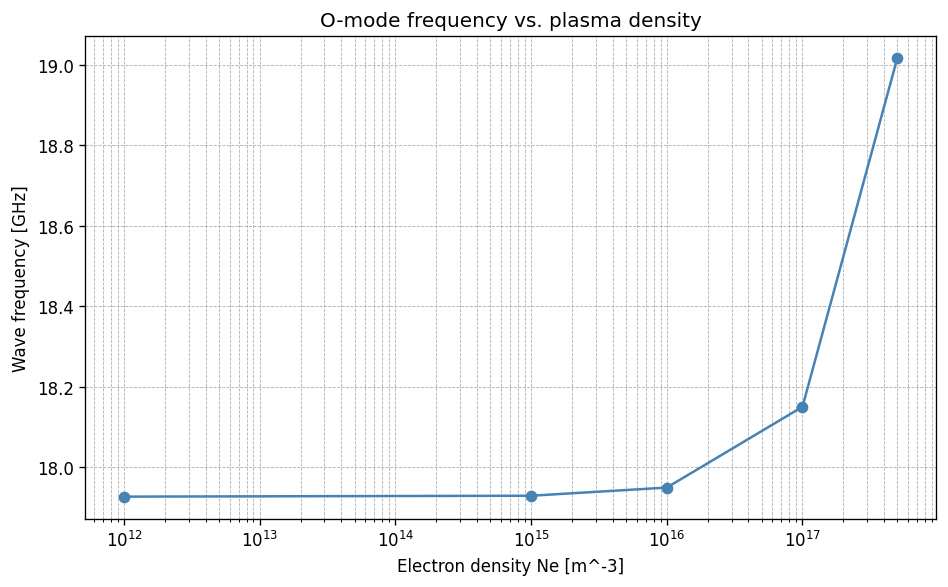

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ne_vals = [r[0] for r in results]
freq_vals = [r[2] for r in results]
ax.semilogx([max(n, 1e12) for n in ne_vals], freq_vals, 'o-', color='steelblue')
ax.set_xlabel('Electron density Ne [m^-3]')
ax.set_ylabel('Wave frequency [GHz]')
ax.set_title('O-mode frequency vs. plasma density')
ax.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.show()

## 4. Save Parameters

In [7]:
solver_uniform.save_all_results()
solver_gauss.save_all_results()
print('Uniform plasma parameters saved.')
print('Gaussian plasma parameters saved.')

Successfully saved 0 modes to saved_parameters/coldplasma_optimized_params.json
Successfully saved 1 modes to saved_parameters/coldplasma_optimized_params.json
Uniform plasma parameters saved.
Gaussian plasma parameters saved.
